#### Import the libraries 

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

#### Load the dataset and add headers

In [4]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

In [5]:
print("Movies Shape :", movies.shape)
print("Ratings Shape :", ratings.shape)

Movies Shape : (9742, 3)
Ratings Shape : (100836, 4)


In [6]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


#### Missing Values

In [8]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [9]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

#### Duplicate Values

In [10]:
movies.duplicated().sum()

np.int64(0)

In [11]:
ratings.duplicated().sum()

np.int64(0)

#### Data Information

In [12]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [13]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


#### Merge Data

In [14]:
movie_data = pd.merge(
    ratings,
    movies,
    on="movieId"
)

movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


#### Calculate Average Rating 

In [15]:
movie_stats = movie_data.groupby(
    ["movieId","title","genres"]
).agg(
    Average_Rating=("rating","mean"),
    Number_of_Ratings=("rating","count")
).reset_index()

#### Top Movies

In [16]:
movie_stats.sort_values(
    "Average_Rating",
    ascending=False
).head()

,movieId,title,genres,Average_Rating,Number_of_Ratings
9693,187717,Won't You Be My Neighbor? (2018),Documentary,5.0,1
4667,6983,Jane Eyre (1944),Drama|Romance,5.0,1
3802,5328,Rain (2001),Drama|Romance,5.0,1
7927,95843,Goodbye Charlie (1964),Comedy|Fantasy|Romance,5.0,1
2934,3941,Sorority House Massacre (1986),Horror,5.0,1


# Recommendation Function

In [17]:
def knowledge_recommendation(
    genre,
    min_rating=4.0,
    min_reviews=50,
    top_n=10
):

    recommendations = movie_stats[
        (movie_stats["genres"].str.contains(genre,case=False))
        &
        (movie_stats["Average_Rating"]>=min_rating)
        &
        (movie_stats["Number_of_Ratings"]>=min_reviews)
    ]

    recommendations = recommendations.sort_values(
        by=["Average_Rating","Number_of_Ratings"],
        ascending=False
    )

    return recommendations[
        [
            "title",
            "genres",
            "Average_Rating",
            "Number_of_Ratings"
        ]
    ].head(top_n)

In [18]:
knowledge_recommendation(
    genre="Comedy"
)

,title,genres,Average_Rating,Number_of_Ratings
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.268041,97
898,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,4.232394,142
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.197068,307
3617,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,4.183333,120
314,Forrest Gump (1994),Comedy|Drama|Romance|War,4.164134,329
862,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,4.161765,136
2992,Snatch (2000),Comedy|Crime|Thriller,4.155914,93
1729,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,4.147727,88
520,Fargo (1996),Comedy|Crime|Drama|Thriller,4.116022,181
7338,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,4.109091,55


#### Genre Distribution

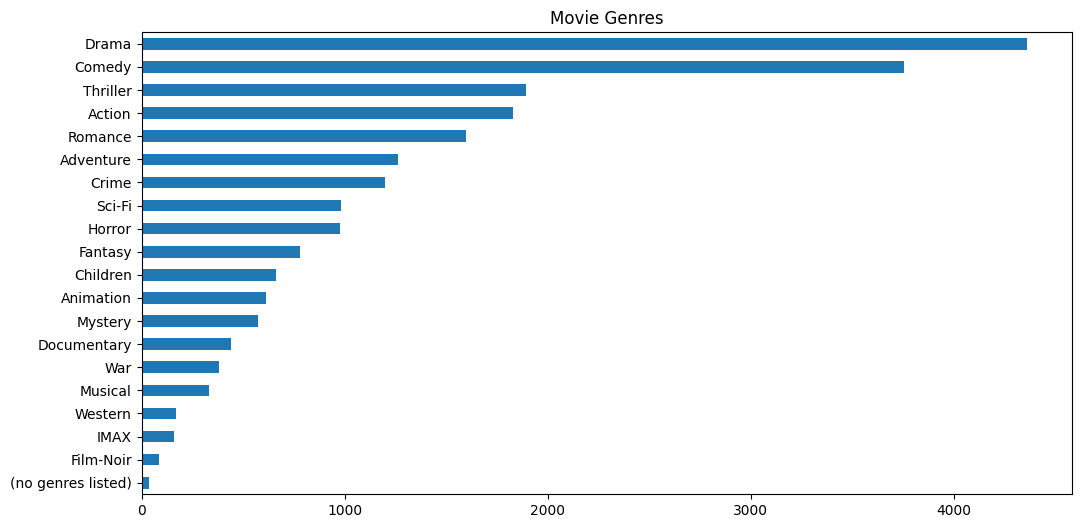

In [19]:
genre_count = movies['genres'].str.get_dummies(sep='|').sum()

plt.figure(figsize=(12,6))

genre_count.sort_values().plot(kind="barh")

plt.title("Movie Genres")

plt.show()

#### Rating Distribution

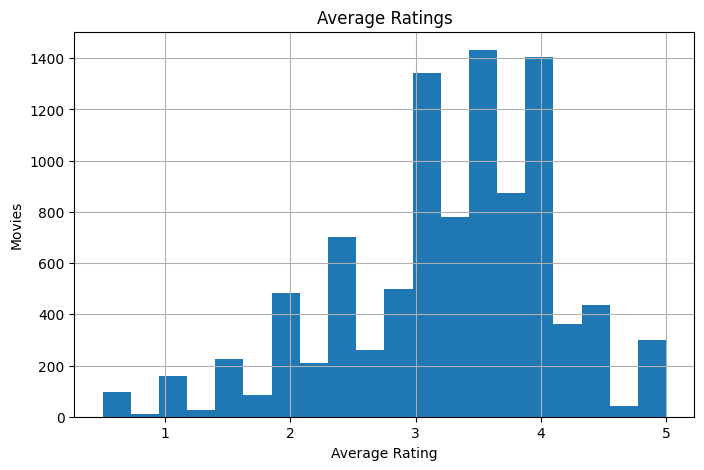

In [20]:
plt.figure(figsize=(8,5))

movie_stats["Average_Rating"].hist(
    bins=20
)

plt.title("Average Ratings")

plt.xlabel("Average Rating")

plt.ylabel("Movies")

plt.show()

#### Top Rated Movies

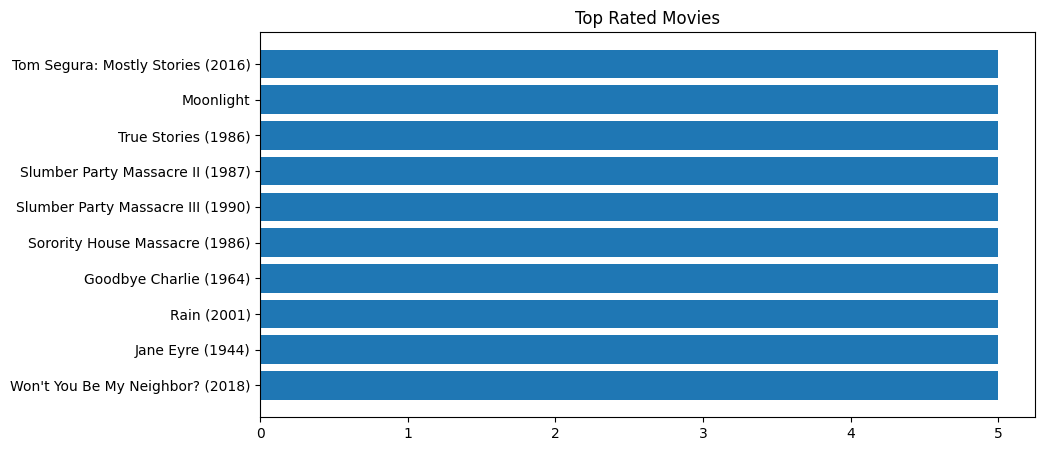

In [21]:
top_movies = movie_stats.sort_values(
    "Average_Rating",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_movies["title"],
    top_movies["Average_Rating"]
)

plt.title("Top Rated Movies")

plt.show()

In [24]:
genre = input("Enter Genre : ")

minimum_rating = float(
    input("Minimum Rating : ")
)

minimum_reviews = int(
    input("Minimum Reviews : ")
)

knowledge_recommendation(
    genre,
    minimum_rating,
    minimum_reviews
)

,title,genres,Average_Rating,Number_of_Ratings
